<!-- # Pipeline smoke test

Raw Citi Bike data -> `RawModelData` -> `ResolvedModelData` -> `Environment` -> `SimulationLog`.

The base scenario reproduces historical **demand** exactly. `FormDeparturesPhase`
re-releases every historical departure (gated by inventory), and
`FormPotentialTripsPhase` assigns each departure a destination and duration from
the OD demand model `P(target | source, commodity)` + mean historical duration.

The initial inventory and dock capacities come from a **sizing run**
(`size_state_for_demand`): the same scenario is run once with saturated inventory
and capacities, and the smallest state that runs its demand with no stockout and
no dock-full is read from that run's journal. This works for any
`demand_scale_factor` -- raise it and the sized state grows to match, so the
limits and the overflow redirect stay in the pipeline but never take effect.

Because targets and durations come from the (aggregate) OD model rather than each
trip's own record, the per-trip journal is **not** identical to history, and the
OD-count matrix drifts slightly under per-period largest-remainder rounding. The
marginal that is preserved exactly is the departures table:
`simulated_departures_df == historical_departures_df`. -->

In [1]:
import pandas as pd

from gbp.loaders.dataloader_raw import RawModelData
from gbp.loaders.dataloader_graph import ResolvedModelData, attach_simulation
from gbp.consumers.simulator.engine import Environment, EnvironmentConfig
from gbp.consumers.simulator import (
    DockArrivals,
    FormDeparturesPhase,
    FormPotentialTripsPhase,
    size_state_for_demand,
)

In [2]:
ubuntu_path = "/mnt/outer/Documents/vlzm/GFDRR_ubuntu/GFDRR/data/raw/202602-citibike-tripdata_1.csv"
mac_path = "/Users/vladislav/Documents/vlzm/GFDRR/data/raw/202601-citibike-tripdata_1.csv"

# Raw model data: read the trip CSV and the live GBFS feed, derive raw entities.
raw_data = RawModelData(
    gbfs_base="https://gbfs.citibikenyc.com/gbfs/en",
    trips_path=mac_path,
    seed=42,
    n_depots=10,
    depot_capacity=9000,
    n_trucks=5,
    truck_capacity_bikes=20,
    truck_rate=50.0,
    electric_bike_rate=5,
    classic_bike_rate=3,
)
graph_data = ResolvedModelData(raw_data, period_len=pd.Timedelta(hours=1))

historical_flows_df_raw = graph_data.historical_flows_df.copy()

/Users/vladislav/Documents/vlzm/GFDRR/gbp/loaders/dataloader_raw.py:244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.stations_capacities_df["capacity"] = 100


In [3]:
phases_canonical = [
    DockArrivals("previous"),
    FormDeparturesPhase(),
    FormPotentialTripsPhase(),
    DockArrivals("same"),
]

# Two demand levels on purpose:
#   sizing_scale -- the demand the state is built to survive with no loss.
#   run_scale    -- the demand the real run actually faces.
# When run_scale > sizing_scale the state is too small for the run: inventory
# runs out (stockout) and arrivals overrun the docks (dock_full). Set the two
# equal to get the clean, no-loss run again.
sizing_scale = 1.5
run_scale = 2.0
number_of_periods = 50

sizing_config = EnvironmentConfig(
    phases=phases_canonical,
    seed=42,
    scenario_id="historical_replay",
    demand_scale_factor=sizing_scale,
    number_of_periods=number_of_periods,
)
run_config = EnvironmentConfig(
    phases=phases_canonical,
    seed=42,
    scenario_id="historical_replay",
    demand_scale_factor=run_scale,
    number_of_periods=number_of_periods,
)

# Size the initial inventory and dock capacities against sizing_scale only.
graph_data.initial_inventory_df, graph_data.facilities_capacities_df = size_state_for_demand(
    graph_data, sizing_config
)

# Run against run_scale. If it is above sizing_scale, the limits now take effect.
env_canonical = Environment(graph_data, run_config)
env_canonical.run()

# Wire the finished run back into the graph-data container's simulated_* slots.
attach_simulation(graph_data, env_canonical.simulated_flows_df)
simulated_flows_df = graph_data.simulated_flows_df
simulated_departures_df = graph_data.simulated_departures_df
historical_departures_df = graph_data.historical_departures_df

In [4]:
simulated_flows_df['reason'].value_counts()

reason
dock_full    2453
stockout     2305
Name: count, dtype: Int64

In [83]:
from gbp.model import (
    arrived_events,
    departed_events,
    finalize_flows,
    flows_to_arrivals,
    flows_to_departures,
    flows_to_od_matrix,
    get_inventory_df,
    phase_rank_by_timing,
)

df_init_inv = graph_data.initial_inventory_df.copy()
df_init_inv['quantity'] = 0

df_inv = get_inventory_df(
    graph_data.historical_flows_df, df_init_inv
)

<Axes: title={'center': 'Cumulative delta between arrivals and demand'}, ylabel='Frequency'>

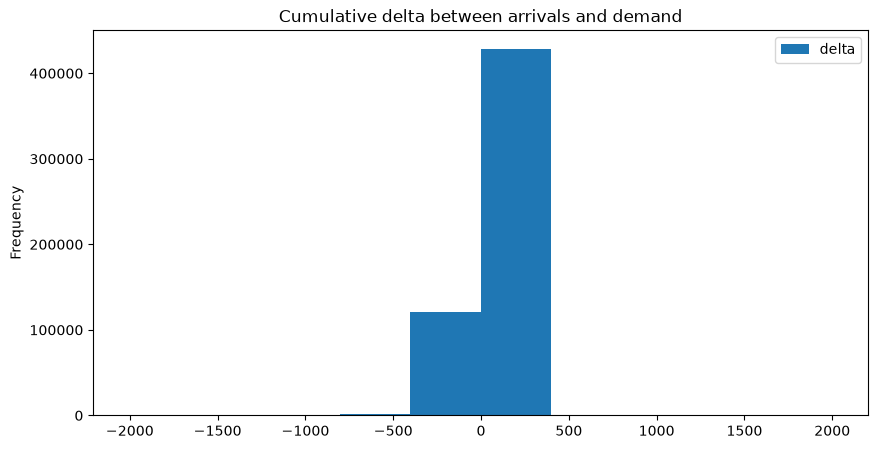

In [73]:
df = (pd.merge(graph_data.historical_demand_df, graph_data.historical_arrivals_df, 
         on = ['period_id', 'facility_id', 'commodity_category'], 
         how = 'outer', 
         suffixes=('_demand', '_arrivals'))
         .fillna(0)
         .sort_values(['period_id', 'facility_id', 'commodity_category']))

df['delta'] = df['quantity_arrivals'] - df['quantity_demand']
df = df[['facility_id', 'commodity_category', 'delta']]
df = df.groupby(['facility_id', 'commodity_category'])['delta'].cumsum().reset_index()
df.sort_values(['delta'], ascending=False)[['delta']].plot.hist(bins=10, figsize=(10, 5), title='Cumulative delta between arrivals and demand')  

# Moment-level inventory and redirect inspection

The journal now carries `step_id` — the inventory time axis *below* the period.
A **step** is one `+1`/`-1` batch (dock arrivals from earlier periods, this
period's departures, same-period dock arrivals, and each redirect round); a
**moment** is the inventory just *before* or just *after* a step (Notations.md
§0.1). Three read-models sit on top of it:

- `inventory_at_moments` — every facility's inventory before/after each step (the
  fine view; per-period inventory is the value at each period's last step).
- `flows_with_inventory` — each event widened with its own facility's inventory
  before and after the event.
- `redirect_neighbor_table` — for one redirect, the full station's neighbours by
  distance out to the station the bike actually reached, each with its free docks
  at the redirect moment, so you can see *why* it landed where it did.

The base replay never overflows a dock, so it has **no** redirects. The first cell
shows the moment tools on the real run; the last two build a small nested-overflow
scenario (a bike skips a now-full nearer neighbour) to exercise
`redirect_neighbor_table`.

In [ ]:
from gbp.model import (
    flows_with_inventory,
    get_inventory_df,
    inventory_at_moments,
    redirect_neighbor_table,
)

initial_inventory_df = graph_data.initial_inventory_df

# 1) The finalized journal now carries `step_id` -- the inventory time axis below
#    the period (one step per +1/-1 batch: dock-previous, departures, dock-same,
#    and each redirect round).
print("step_id range:",
      int(simulated_flows_df["step_id"].min()), "..", int(simulated_flows_df["step_id"].max()))
display(simulated_flows_df.head(8))

# 2) Inventory at every moment: each facility's value before/after each step.
moments_df = inventory_at_moments(simulated_flows_df, initial_inventory_df)
display(moments_df.head(8))

# 3) The journal widened with each event's own facility inventory before/after.
wide_flows_df = flows_with_inventory(simulated_flows_df, initial_inventory_df)
display(wide_flows_df.head(8))

# 4) Sanity: the fine view coarsens back to per-period inventory exactly
#    (a period's inventory is the value at its last step).
last_step = moments_df.groupby("period_id")["step_id"].transform("max") == moments_df["step_id"]
period_end_df = (moments_df[last_step]
                 .rename(columns={"inventory_after": "quantity_eop"})
                 [["period_id", "facility_id", "commodity_category", "quantity_eop"]])
coarse_df = get_inventory_df(simulated_flows_df, initial_inventory_df)
check_df = coarse_df.merge(period_end_df,
                           on=["period_id", "facility_id", "commodity_category"],
                           suffixes=("_coarse", "_fine"))
assert (check_df["quantity_eop_coarse"] == check_df["quantity_eop_fine"]).all()
print(f"OK: inventory_at_moments last step == get_inventory_df ({len(check_df)} rows match)")

In [9]:
# The base replay never overflows a dock, so it has no redirects. Build a small
# scenario that does, with a nested overflow: five bikes aim at the full station
# s3; the nearest free neighbour s2 holds only two, then s4 holds two, then s5 --
# so the redirect spills across neighbours and later bikes skip a now-full one.
# (`tests` is not installed, so add the repo root to the path before importing.)
import pathlib
import sys

_repo_root = pathlib.Path.cwd()
while not (_repo_root / "pyproject.toml").exists() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from tests import scenarios

# Filler trips in period 6 only exist to create the facilities s2/s4/s5.
_trips = [("s1", "s3", 0, 1)] * 5 + [("s1", "s2", 6, 7), ("s1", "s4", 6, 7), ("s1", "s5", 6, 7)]
redirect_resolved = scenarios.build_resolved(
    _trips, capacities={"s3": 0, "s2": 2, "s4": 2, "s5": 10}, initial_inventory={"s1": 8}
)
redirect_flows_df, _redirect_state = scenarios.run(redirect_resolved)

print("redirected events:", int((redirect_flows_df["event_type"] == "redirected").sum()))
display(flows_with_inventory(redirect_flows_df, redirect_resolved.initial_inventory_df))

redirected events: 7


,flow_id,move_id,event_id,period_id,flow_type,event_type,commodity_category,source_id,planned_target_id,realized_target_id,...,realized_end_period,resource_id,quantity,reason,phase_rank,phase_round,step_id,facility_id,inventory_before,inventory_after
0,sim_0_0,0,0,0,user_trip,departed,classic_bike,s1,s3,<NA>,...,<NA>,<NA>,1,<NA>,1,0,0,s1,8,3
1,sim_0_1,0,0,0,user_trip,departed,classic_bike,s1,s3,<NA>,...,<NA>,<NA>,1,<NA>,1,0,0,s1,8,3
2,sim_0_2,0,0,0,user_trip,departed,classic_bike,s1,s3,<NA>,...,<NA>,<NA>,1,<NA>,1,0,0,s1,8,3
3,sim_0_3,0,0,0,user_trip,departed,classic_bike,s1,s3,<NA>,...,<NA>,<NA>,1,<NA>,1,0,0,s1,8,3
4,sim_0_4,0,0,0,user_trip,departed,classic_bike,s1,s3,<NA>,...,<NA>,<NA>,1,<NA>,1,0,0,s1,8,3
5,sim_0_0,0,1,1,user_trip,redirected,classic_bike,s1,s3,<NA>,...,1,<NA>,1,dock_full,0,1,1,<NA>,<NA>,<NA>
6,sim_0_0,1,2,1,user_trip,departed,classic_bike,s3,s2,<NA>,...,1,<NA>,1,<NA>,0,1,1,<NA>,<NA>,<NA>
7,sim_0_0,1,3,1,user_trip,arrived,classic_bike,s3,s2,s2,...,1,<NA>,1,<NA>,0,1,1,s2,0,2
8,sim_0_1,0,1,1,user_trip,redirected,classic_bike,s1,s3,<NA>,...,1,<NA>,1,dock_full,0,1,1,<NA>,<NA>,<NA>
9,sim_0_1,1,2,1,user_trip,departed,classic_bike,s3,s2,<NA>,...,1,<NA>,1,<NA>,0,1,1,<NA>,<NA>,<NA>


In [10]:
# Explain the redirect that docked at s4: by the time this bike was redirected,
# the nearer neighbour s2 was already full (free_before == 0), which is why it
# skipped s2 and landed at s4 (free_before >= 1). redirect_neighbor_table shows
# the full station's neighbours by distance out to where the bike actually docked,
# each with its free docks at the redirect moment -- the whole story in one table.
_dockings = flows_with_inventory(redirect_flows_df, redirect_resolved.initial_inventory_df)
_dockings = _dockings[(_dockings["move_id"] == 1) & (_dockings["event_type"] == "arrived")
                      & (_dockings["period_id"] == 1)]
example_flow_id = _dockings.loc[_dockings["realized_target_id"] == "s4", "flow_id"].iloc[0]
print("explaining redirect of flow:", example_flow_id, "(docked at s4)")

redirect_neighbor_table(
    redirect_flows_df,
    redirect_resolved.initial_inventory_df,
    redirect_resolved.facilities_geo_df,
    example_flow_id,
    capacities=redirect_resolved.facilities_capacities_df,
)

explaining redirect of flow: sim_0_2 (docked at s4)


,flow_id,step_id,period_id,planned_target_id,realized_target_id,commodity_category,neighbor_rank,facility_id,distance_sq,inventory_before,inventory_after,capacity,free_before,free_after
0,sim_0_2,2,1,s3,s4,classic_bike,0,s2,0.000002,2,2,2,0,0
1,sim_0_2,2,1,s3,s4,classic_bike,1,s4,0.000002,0,2,2,2,0
